# Data Loading and Basic Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold
import warnings
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix
)
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier
import plotly.graph_objects as go

In [2]:
# 1. Load all tables
patients = pd.read_csv("patients.csv")
diagnoses = pd.read_csv("diagnoses.csv")
medications = pd.read_csv("medications.csv")
lab_results = pd.read_csv("lab_results.csv")
outcomes = pd.read_csv("outcomes.csv")

# 2. Standardize patient_id format
for df in [patients, diagnoses, medications, lab_results, outcomes]:
    df["patient_id"] = df["patient_id"].astype(str)

# 3. Check duplicates
for name, df in zip(["patients", "diagnoses", "medications", "lab_results", "outcomes"],
                    [patients, diagnoses, medications, lab_results, outcomes]):
    print(f"{name} duplicate rows: {df.duplicated().sum()}")
    df.drop_duplicates(inplace=True)

# 4. Check missing values
print("Missing value ratio per table:")
for name, df in zip(["patients", "diagnoses", "medications", "lab_results", "outcomes"],
                    [patients, diagnoses, medications, lab_results, outcomes]):
    print(f"\n{name}:")
    print(df.isnull().mean().sort_values(ascending=False).head(10))

patients duplicate rows: 0
diagnoses duplicate rows: 0
medications duplicate rows: 0
lab_results duplicate rows: 0
outcomes duplicate rows: 0
Missing value ratio per table:

patients:
patient_id                   0.0
age                          0.0
dx_osteoarthritis            0.0
dx_hypothyroidism            0.0
dx_anxiety                   0.0
dx_depression                0.0
dx_asthma                    0.0
dx_copd                      0.0
dx_chronic_kidney_disease    0.0
dx_atrial_fibrillation       0.0
dtype: float64

diagnoses:
secondary_diagnoses    0.41566
secondary_icd10s       0.41566
patient_id             0.00000
visit_date             0.00000
visit_type             0.00000
primary_diagnosis      0.00000
primary_icd10          0.00000
provider_specialty     0.00000
dtype: float64

medications:
patient_id       0.0
medication       0.0
dose             0.0
unit             0.0
frequency        0.0
indication       0.0
start_date       0.0
duration_days    0.0
is_generic    

In [3]:
# 5. Handle critical missing values
# ----------------------
# diagnoses: 41.5% missing in secondary_diagnoses & secondary_icd10s
# ----------------------
# Fill with empty string (meaning "no secondary diagnoses")
diagnoses["secondary_diagnoses"] = diagnoses["secondary_diagnoses"].fillna("")
diagnoses["secondary_icd10s"] = diagnoses["secondary_icd10s"].fillna("")

# ----------------------
# outcomes: 85% missing in days_to_readmission
# ----------------------
# 85% missing = this column is almost useless → drop it
outcomes = outcomes.drop(columns=["days_to_readmission"])

# ----------------------
# patients & medications & lab_results: NO MISSING VALUES → DO NOTHING
# ----------------------

In [4]:
def convert_binary_to_bool(df):
    """
    Automatically detect the columns in the dataset where the values are only 0 and 1, and convert them to boolean type (True/False).
    """
    for col in df.columns:
        unique_vals = sorted(df[col].dropna().unique())

        if unique_vals == [0, 1]:
            df[col] = df[col].astype("boolean")
            print(f"Has been converted to boolean type: {col}")
    
    print("\nAll the 0/1 columns have been converted to boolean type!")
    return df

# Feature Engineering for Sub-table

## About <patients.csv>

In [5]:
patients

,patient_id,age,sex,bmi,systolic_bp,diastolic_bp,heart_rate,temperature_f,smoking_status,alcohol_use,...,dx_heart_failure,dx_atrial_fibrillation,dx_chronic_kidney_disease,dx_copd,dx_asthma,dx_depression,dx_anxiety,dx_hypothyroidism,dx_osteoarthritis,dx_type1_diabetes
0,P0000001,66,M,23.5,148,81,64,98.4,former,light,...,0,0,1,0,0,0,0,0,1,0
1,P0000002,75,M,24.8,158,86,45,99.5,never,moderate,...,0,0,0,0,1,0,0,0,1,0
2,P0000003,82,M,17.8,135,57,90,98.2,never,light,...,0,0,1,0,0,0,0,0,0,0
3,P0000004,73,F,28.1,118,83,102,98.9,former,moderate,...,0,0,0,0,0,0,0,0,0,0
4,P0000005,86,F,30.6,156,81,56,98.7,never,heavy,...,0,0,0,0,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,P0099996,37,M,24.9,106,101,93,98.9,never,light,...,0,0,0,0,0,0,0,0,0,0
99996,P0099997,37,F,27.8,80,95,63,98.7,never,moderate,...,0,0,0,0,0,0,0,1,0,0
99997,P0099998,50,F,28.5,115,83,53,99.2,never,moderate,...,0,0,0,0,0,0,0,0,0,0
99998,P0099999,85,M,34.6,149,73,65,98.5,never,none,...,0,0,0,1,1,0,0,0,1,0


In [6]:
# Perform the conversion
patients = convert_binary_to_bool(patients)

Has been converted to boolean type: dx_hypertension
Has been converted to boolean type: dx_type2_diabetes
Has been converted to boolean type: dx_hyperlipidemia
Has been converted to boolean type: dx_obesity
Has been converted to boolean type: dx_coronary_artery_disease
Has been converted to boolean type: dx_heart_failure
Has been converted to boolean type: dx_atrial_fibrillation
Has been converted to boolean type: dx_chronic_kidney_disease
Has been converted to boolean type: dx_copd
Has been converted to boolean type: dx_asthma
Has been converted to boolean type: dx_depression
Has been converted to boolean type: dx_anxiety
Has been converted to boolean type: dx_hypothyroidism
Has been converted to boolean type: dx_osteoarthritis
Has been converted to boolean type: dx_type1_diabetes

All the 0/1 columns have been converted to boolean type!


In [7]:
# 1. One-hot encoding for categorical variables
original_cols = patients.columns.tolist() # List of original column names
cat_cols_pat = patients.select_dtypes(exclude=[np.number]).columns.drop("patient_id") # List of non-numeric column names
for col in cat_cols_pat:
    if patients[col].nunique() > 10: # 10 is empirical value
        print(f"High cardinality column {col}, unique values: {patients[col].nunique()}")
        patients.drop(col, axis=1, inplace=True)
    else:
        patients = pd.get_dummies(patients, columns=[col], prefix=col, drop_first=True)

# 2. Standardize numerical features
scaler = StandardScaler()
num_cols_pat = patients.select_dtypes(include=[np.number]).columns.drop(["patient_id"], errors="ignore") # List of numeric column names
patients[num_cols_pat] = scaler.fit_transform(patients[num_cols_pat])

new_cols = patients.columns.tolist() # List of new column names
added_cols = [col for col in new_cols if col not in original_cols]
patients[added_cols]

,sex_M,smoking_status_former,smoking_status_never,alcohol_use_light,alcohol_use_moderate,alcohol_use_none,exercise_level_moderate,exercise_level_sedentary,exercise_level_vigorous,insurance_type_medicaid,...,dx_heart_failure_True,dx_atrial_fibrillation_True,dx_chronic_kidney_disease_True,dx_copd_True,dx_asthma_True,dx_depression_True,dx_anxiety_True,dx_hypothyroidism_True,dx_osteoarthritis_True,dx_type1_diabetes_True
0,True,True,False,True,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
1,True,False,True,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,True,False,True,True,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,False,True,False,False,True,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,True,False,False,...,False,False,False,False,True,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,True,False,True,True,False,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
99996,False,False,True,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
99997,False,False,True,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
99998,True,False,True,False,False,True,False,False,False,False,...,False,False,False,True,True,False,False,False,True,False


## About <diagnoses.csv>

In [8]:
diagnoses

,patient_id,visit_date,visit_type,primary_diagnosis,primary_icd10,secondary_diagnoses,secondary_icd10s,provider_specialty
0,P0000001,2018-07-26,telehealth,hyperlipidemia,E78.5,chronic_kidney_disease,N18.3,internal_medicine
1,P0000001,2020-04-09,outpatient,hyperlipidemia,E78.5,chronic_kidney_disease|osteoarthritis,N18.3|M19.90,nephrology
2,P0000001,2023-08-12,emergency,chronic_kidney_disease,N18.3,hyperlipidemia,E78.5,internal_medicine
3,P0000001,2022-11-04,outpatient,osteoarthritis,M19.90,hyperlipidemia|chronic_kidney_disease,E78.5|N18.3,internal_medicine
4,P0000002,2020-07-29,outpatient,osteoarthritis,M19.90,type2_diabetes,E11.9,nephrology
...,...,...,...,...,...,...,...,...
274587,P0099999,2018-04-24,outpatient,copd,J44.1,osteoarthritis,M19.90,nephrology
274588,P0100000,2020-07-01,inpatient,osteoarthritis,M19.90,,,internal_medicine
274589,P0100000,2019-08-30,inpatient,asthma,J45.909,hypertension,I10,internal_medicine
274590,P0100000,2022-08-28,emergency,asthma,J45.909,hypertension|osteoarthritis,I10|M19.90,cardiology


In [9]:
# 1. Split secondary ICD codes and diagnoses into list
diagnoses["secondary_icd_list"] = diagnoses["secondary_icd10s"].str.split("|")
diagnoses["secondary_diag_list"] = diagnoses["secondary_diagnoses"].str.split("|")

# 2. Extract the four core columns
primary_mapping = diagnoses[["primary_icd10", "primary_diagnosis"]].drop_duplicates()
primary_mapping.columns = ["icd10_code", "diagnoses_name"]
diagnoses_exploded = diagnoses.explode(["secondary_icd_list", "secondary_diag_list"])
secondary_mapping = diagnoses_exploded[["secondary_icd_list", "secondary_diag_list"]].rename(
    columns={
        "secondary_icd_list": "icd10_code",
        "secondary_diag_list": "diagnoses_name"
    }
).drop_duplicates()

# 3. Merge the diagnostic mappings and generate a complete comparison table
full_mapping = pd.concat([primary_mapping, secondary_mapping], ignore_index=True)
full_mapping = full_mapping.drop_duplicates().reset_index(drop=True)
full_mapping = full_mapping[
    (full_mapping["icd10_code"].str.strip() != "") &
    (full_mapping["diagnoses_name"].str.strip() != "")
] # Delete blank lines

print("ICD Coding - Diagnosis Name Mapping Table：")
print(full_mapping)
full_mapping.to_csv("icd_code_to_name_mapping.csv", index=False, encoding="utf-8")

ICD Coding - Diagnosis Name Mapping Table：
   icd10_code           diagnoses_name
0       E78.5           hyperlipidemia
1       N18.3   chronic_kidney_disease
2      M19.90           osteoarthritis
3       E11.9           type2_diabetes
4         I10             hypertension
5      I25.10  coronary_artery_disease
6       E66.9                  obesity
7       F32.9               depression
8       J44.1                     copd
9      I48.91      atrial_fibrillation
10      F41.9                  anxiety
11    J45.909                   asthma
12      E03.9           hypothyroidism
13      E10.9           type1_diabetes
14      I50.9            heart_failure


In [10]:
# 1. Aggregate visit features
diag_agg = diagnoses.groupby("patient_id").agg(
    total_visits=("visit_date", "count"),
    telehealth_visits=("visit_type", lambda x: sum(x == "telehealth")),
    emergency_visits=("visit_type", lambda x: sum(x == "emergency")),
    inpatient_visits=("visit_type", lambda x: sum(x == "inpatient")),
    outpatient_visits=("visit_type", lambda x: sum(x == "outpatient"))
).reset_index()

# 2. Collect all ICD codes (primary + secondary)
# 2.1 Extract the primary diagnosis ICD
primary_icds = diagnoses[["patient_id", "primary_icd10"]].rename(columns={"primary_icd10": "icd_code"})

# 2.2 Extract the secondary diagnosis ICD
secondary_icds = diagnoses[["patient_id", "secondary_icd_list"]].explode("secondary_icd_list")
secondary_icds = secondary_icds.rename(columns={"secondary_icd_list": "icd_code"})

# 2.3 Filter out null values
all_icds_long = pd.concat([primary_icds, secondary_icds], ignore_index=True)
all_icds_long = all_icds_long[all_icds_long["icd_code"] != ""].dropna(subset=["icd_code"])

# 3. Get top 15 frequent ICD codes
icd_series = all_icds_long["icd_code"].value_counts()
top_icds = icd_series.index

# 4. Create one-hot encoding for ICDs per patient
# 4.1 Group patients by patient ID and ICD number, and count the occurrence frequency of each ICD for each patient.
patient_icd_counts = all_icds_long.groupby(["patient_id", "icd_code"]).size().unstack(fill_value=0)

# 4.2 Fill in the missing ICD codes with 0.
patient_icd = patient_icd_counts.reindex(columns=top_icds, fill_value=0)

# 4.3 Reset the index and generate a standard DataFrame
icd_df = patient_icd.reset_index()

# 5. Convert to dataframe and merge with diag_agg
diag_agg = diag_agg.merge(icd_df, on="patient_id", how="left").fillna(0)

In [11]:
# Perform the conversion
diag_agg = convert_binary_to_bool(diag_agg)


All the 0/1 columns have been converted to boolean type!


In [12]:
diag_agg

,patient_id,total_visits,telehealth_visits,emergency_visits,inpatient_visits,outpatient_visits,I10,E66.9,E78.5,N18.3,...,M19.90,F41.9,F32.9,I25.10,J45.909,J44.1,E03.9,I50.9,I48.91,E10.9
0,P0000001,4,1,1,0,2,0,0,4,4,...,2,0,0,0,0,0,0,0,0,0
1,P0000002,6,1,0,0,5,4,3,0,0,...,3,0,0,0,3,0,0,0,0,0
2,P0000003,1,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,P0000004,2,0,0,0,2,1,1,2,0,...,0,0,0,0,0,0,0,0,0,0
4,P0000005,1,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,P0099996,1,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
99996,P0099997,4,0,1,0,3,0,4,0,0,...,0,0,0,0,0,0,3,0,0,0
99997,P0099998,3,0,0,0,3,0,0,3,0,...,0,0,0,0,0,0,0,0,0,0
99998,P0099999,3,0,1,0,2,0,0,0,0,...,3,0,0,0,1,1,0,0,0,0



=== Analysis of ICD Feature Sparsity ===
Proportion of zero values: 83.15%


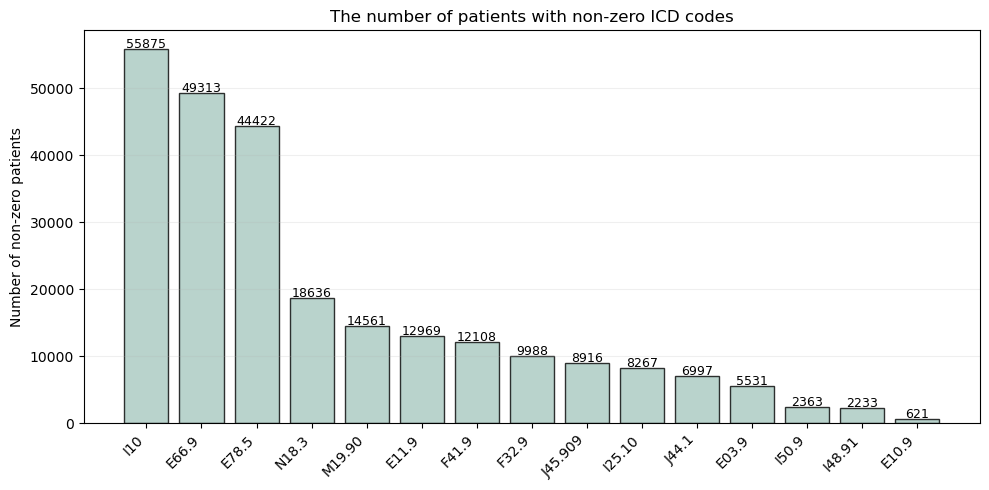

In [13]:
visit_cols = ['total_visits', 'telehealth_visits', 'emergency_visits', 'inpatient_visits', 'outpatient_visits']
icd_cols = [col for col in diag_agg.columns if col not in ['patient_id'] + visit_cols]

# 1. Sporadicity analysis
zero_ratio = (diag_agg[icd_cols] == 0).sum().sum() / (diag_agg[icd_cols].shape[0] * diag_agg[icd_cols].shape[1])
print(f"\n=== Analysis of ICD Feature Sparsity ===")
print(f"Proportion of zero values: {zero_ratio:.2%}")

# 2. Visualization of the distribution of the number of patients with non-zero ICD values
icd_cols = [col for col in diag_agg.columns if col not in ["patient_id"] + visit_cols]
icd_nonzero = diag_agg[icd_cols].astype(bool).sum(axis=0).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(icd_nonzero.index, icd_nonzero.values, color='#a8c8c0', edgecolor="black", alpha=0.8)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 150,
             f'{int(height)}', ha='center', fontsize=9)

plt.title("The number of patients with non-zero ICD codes")
plt.ylabel("Number of non-zero patients")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [14]:
# Optimize data types to significantly reduce memory usage
# 1. Number of visits column: Using int32 is sufficient to cover the maximum number.
visit_cols = ["total_visits", "telehealth_visits", "emergency_visits", "inpatient_visits", "outpatient_visits"]
diag_agg[visit_cols] = diag_agg[visit_cols].astype("int32")

# 2. ICD entry: Use int8 (count usually < 10)
icd_cols = [col for col in diag_agg.columns if col not in ["patient_id"] + visit_cols]
diag_agg[icd_cols] = diag_agg[icd_cols].astype("int8")

# Check the optimized memory usage
print(f"Optimized total memory usage: {diag_agg.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

Optimized total memory usage: 9.54 MB


## About <medications.csv>

In [15]:
medications

,patient_id,medication,dose,unit,frequency,indication,start_date,duration_days,is_generic,adherence_pct
0,P0000001,Rosuvastatin,10.0,mg,daily,hyperlipidemia,2020-03-06,30,1,84.5
1,P0000001,Lisinopril,10.0,mg,daily,chronic_kidney_disease,2020-01-22,30,1,81.0
2,P0000001,Erythropoietin,4000.0,units,weekly,chronic_kidney_disease,2021-05-24,90,0,77.1
3,P0000001,Ibuprofen,400.0,mg,three times daily,osteoarthritis,2020-03-16,180,1,90.2
4,P0000002,Metoprolol,25.0,mg,twice daily,hypertension,2018-12-21,365,1,100.0
...,...,...,...,...,...,...,...,...,...,...
364169,P0100000,Lisinopril,10.0,mg,daily,hypertension,2021-05-19,90,1,71.5
364170,P0100000,Amlodipine,5.0,mg,daily,hypertension,2020-05-23,365,1,37.5
364171,P0100000,Albuterol,90.0,mcg,as needed,asthma,2020-08-03,90,0,100.0
364172,P0100000,Ibuprofen,400.0,mg,three times daily,osteoarthritis,2019-11-30,180,1,66.2


In [16]:
# Perform the conversion
medications = convert_binary_to_bool(medications)

Has been converted to boolean type: is_generic

All the 0/1 columns have been converted to boolean type!


In [17]:
# 1. Core clinical features statistical aggregation
med_stats = medications.groupby("patient_id").agg(
    total_medications=("medication", "count"),
    avg_prescription_duration=("duration_days", "mean"),
    avg_adherence_pct=("adherence_pct", "mean"),
    low_adherence_count=("adherence_pct", lambda x: (x < 80).sum()),
    generic_med_ratio=("is_generic", "mean")
).reset_index()

# 2. One-hot for medication frequency (how often drugs are taken)
freq_dummies = pd.get_dummies(medications[["patient_id", "frequency"]], 
                              prefix="freq", columns=["frequency"])
freq_agg = freq_dummies.groupby("patient_id").max().reset_index()

# 3. One-hot for top 15 indications (why drugs are prescribed → diagnoses table)
top_indications = medications["indication"].value_counts().head(15).index
ind_subset = medications[medications["indication"].isin(top_indications)]
ind_dummies = pd.get_dummies(ind_subset[["patient_id", "indication"]], 
                             prefix="ind", columns=["indication"])
ind_agg = ind_dummies.groupby("patient_id").max().reset_index()

# 4. One-hot for top 15 medication names (which drugs patients use)
top_meds = medications["medication"].value_counts().head(15).index
med_subset = medications[medications["medication"].isin(top_meds)]
med_dummies = pd.get_dummies(med_subset[["patient_id", "medication"]], 
                             prefix="med", columns=["medication"])
med_agg_dummies = med_dummies.groupby("patient_id").max().reset_index()

# 5. Merge all medication features
med_agg = med_stats.merge(freq_agg, on="patient_id", how="left")
med_agg = med_agg.merge(ind_agg, on="patient_id", how="left")
med_agg = med_agg.merge(med_agg_dummies, on="patient_id", how="left")
med_agg = med_agg.fillna(0)

In [18]:
med_agg

,patient_id,total_medications,avg_prescription_duration,avg_adherence_pct,low_adherence_count,generic_med_ratio,freq_as needed,freq_daily,freq_three times daily,freq_twice daily,...,med_Erythropoietin,med_Fluticasone,med_Ibuprofen,med_Levothyroxine,med_Lisinopril,med_Losartan,med_Metoprolol,med_Rosuvastatin,med_Sertraline,med_Simvastatin
0,P0000001,4,82.500000,83.200,1,0.75,False,True,True,False,...,True,False,True,False,True,False,False,True,False,False
1,P0000002,4,158.750000,72.750,2,1.0,True,True,False,True,...,False,False,False,False,False,False,True,False,False,False
2,P0000003,4,97.500000,88.750,1,1.0,True,True,False,False,...,True,False,False,False,True,False,False,False,False,False
3,P0000004,4,151.250000,85.075,2,0.75,False,True,False,False,...,False,False,False,False,True,True,False,False,False,True
4,P0000005,6,135.833333,86.100,1,0.666667,True,True,False,True,...,False,True,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94062,P0099996,1,90.000000,66.000,1,1.0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
94063,P0099997,1,30.000000,90.900,0,0.0,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
94064,P0099998,1,180.000000,100.000,0,1.0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
94065,P0099999,10,157.000000,75.290,6,0.6,True,True,True,True,...,False,True,True,False,False,True,True,False,False,True


## About <lab_results.csv>

In [19]:
lab_results

,patient_id,test_date,test_name,value,unit,reference_low,reference_high,flag,is_abnormal,delta_from_normal
0,P0000001,2019-03-21,WBC,9.551,K/uL,4.5,11.0,normal,0,1.801
1,P0000001,2019-03-21,total_cholesterol,225.729,mg/dL,100.0,199.0,high,1,76.229
2,P0000001,2019-03-21,HDL,67.620,mg/dL,40.0,100.0,normal,0,-2.380
3,P0000001,2019-03-21,potassium,4.423,mEq/L,3.5,5.0,normal,0,0.173
4,P0000001,2019-03-21,sodium,142.463,mEq/L,136.0,145.0,normal,0,1.963
...,...,...,...,...,...,...,...,...,...,...
2827717,P0100000,2019-08-30,ALT,35.304,U/L,7.0,56.0,normal,0,3.804
2827718,P0100000,2019-08-30,AST,18.658,U/L,10.0,40.0,normal,0,-6.342
2827719,P0100000,2019-08-30,hemoglobin,12.940,g/dL,12.0,17.5,normal,0,-1.810
2827720,P0100000,2019-08-30,glucose_fasting,89.697,mg/dL,70.0,99.0,normal,0,5.197


In [20]:
# Perform the conversion
lab_results = convert_binary_to_bool(lab_results)

Has been converted to boolean type: is_abnormal

All the 0/1 columns have been converted to boolean type!


In [21]:
# 1. Get latest lab results per patient and test
lab_sorted = lab_results.sort_values(["patient_id", "test_date"], ascending=[True, False])
lab_latest = lab_sorted.drop_duplicates(subset=["patient_id", "test_name"], keep="first")
# Avoiding the interference of historical data, it can better reflect the current health status.

# 2. Select top 20 most frequent tests
top_tests = lab_results["test_name"].value_counts().head(20).index
lab_wide = lab_latest.pivot(index="patient_id", columns="test_name", values="value").reset_index()
lab_wide = lab_wide[["patient_id"] + list(top_tests)].fillna(0)

# 3. Standardize lab values
scaler_lab = StandardScaler()
lab_wide[top_tests] = scaler_lab.fit_transform(lab_wide[top_tests])

# 4. Aggregate lab statistics
lab_stats = lab_results.groupby("patient_id").agg(
    abnormal_test_count=("is_abnormal", "sum"),
    abnormal_test_ratio=("is_abnormal", "mean")
).reset_index()

# 5. Merge stats and wide table
lab_agg = lab_stats.merge(lab_wide, on="patient_id", how="left").fillna(0)

In [22]:
lab_agg

,patient_id,abnormal_test_count,abnormal_test_ratio,WBC,glucose_fasting,creatinine,potassium,sodium,ALT,AST,hemoglobin,LDL,total_cholesterol,triglycerides,HDL,eGFR,HbA1c,BNP,troponin_I,TSH
0,P0000001,24,0.461538,0.302615,0.560570,0.414735,1.492517,-0.459662,-0.529113,-1.121716,0.791038,0.522903,0.916692,0.659525,1.180350,2.154650,-0.434425,-0.356746,-0.314423,-0.267904
1,P0000002,10,0.222222,0.603104,-0.479658,-0.495657,-0.139796,1.772851,1.139001,-0.323665,0.603842,-1.126500,-1.180335,-0.982233,-1.071396,-0.475475,1.485023,-0.356746,-0.314423,-0.267904
2,P0000003,4,0.153846,1.191176,-1.094970,1.067633,2.382507,0.132529,0.345849,-0.197403,-0.113194,-0.554811,0.366791,-0.982233,-1.071396,1.799776,-0.434425,3.198542,3.478088,-0.267904
3,P0000004,11,0.305556,0.645504,0.601054,-0.447650,0.758176,1.306941,0.798922,0.596440,2.007261,0.734559,0.668699,1.675541,1.180097,-0.475475,-0.434425,-0.356746,-0.314423,-0.267904
4,P0000005,7,0.269231,0.582825,-0.142103,-0.470780,1.408707,1.765540,-2.290165,-2.237024,1.886843,0.906304,0.693561,0.077852,0.635228,-0.475475,-0.434425,-0.356746,-0.314423,3.506962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,P0099996,8,0.333333,0.121032,0.182130,-0.496530,0.562617,-1.705854,0.281282,0.425887,-0.016859,1.307456,0.804412,-0.176679,0.518488,-0.475475,-0.434425,-0.356746,-0.314423,-0.267904
99996,P0099997,0,0.0,-0.634798,-0.914775,-0.495657,-0.582796,1.248453,1.303722,0.544733,1.087704,-1.126500,-1.180335,-0.982233,-1.071396,-0.475475,-0.434425,-0.356746,-0.314423,4.630133
99997,P0099998,12,0.333333,0.146841,1.380770,-0.519660,0.391005,1.061690,-0.498419,-0.618675,-2.915653,0.755469,0.930611,1.342773,1.165245,-0.475475,-0.434425,-0.356746,-0.314423,-0.267904
99998,P0099999,8,0.333333,1.460325,1.227391,-0.421027,-0.838219,0.204974,0.414819,1.802937,1.306646,1.368304,0.972198,0.840815,0.611868,-0.475475,-0.434425,-0.356746,-0.314423,-0.267904


## About <outcomes.csv>

In [23]:
outcomes

,patient_id,admission_date,discharge_date,length_of_stay_days,icu_admission,icu_days,in_hospital_death,discharge_disposition,readmitted_30d,primary_drg,total_charges_usd
0,P0000002,2024-08-06,2024-08-09,3,0,0,0,home_health,0,291,8589.79
1,P0000003,2022-05-06,2022-05-08,2,0,0,0,hospice,1,392,22628.17
2,P0000011,2021-12-30,2022-01-08,9,0,0,0,rehab,0,392,27565.97
3,P0000014,2022-06-30,2022-07-04,4,0,0,0,home,0,194,10332.33
4,P0000040,2020-09-19,2020-09-20,1,0,0,0,rehab,0,470,2389.61
...,...,...,...,...,...,...,...,...,...,...,...
10996,P0099972,2019-10-07,2019-10-25,18,0,0,0,home,0,392,15017.53
10997,P0099984,2023-11-01,2023-11-05,4,0,0,0,home,0,392,34502.78
10998,P0099991,2024-09-12,2024-09-17,5,0,0,0,home_health,0,194,32636.67
10999,P0099992,2018-06-22,2018-06-27,5,0,0,0,home_health,0,292,3082.48


In [24]:
# Perform the conversion
outcomes = convert_binary_to_bool(outcomes)

Has been converted to boolean type: icu_admission
Has been converted to boolean type: in_hospital_death
Has been converted to boolean type: readmitted_30d

All the 0/1 columns have been converted to boolean type!


In [25]:
# 1. One-hot encode discharge_disposition
outcomes_processed = pd.get_dummies(
    outcomes,
    columns=["discharge_disposition"],
    prefix="discharge",
    drop_first=True
)

# 2. Deduplicate: Keep only 1 row per patient (max value for binary labels)
outcome_agg = outcomes_processed.groupby("patient_id").agg({
    "readmitted_30d": "max",
    "in_hospital_death": "max",
    "icu_admission": "max",
    "length_of_stay_days": "mean",
    "admission_date": "count"
}).reset_index()
outcome_agg.rename(columns={
    "length_of_stay_days": "avg_length_of_stay",
    "admission_date": "total_admissions"
}, inplace=True)

# 3. Ensure binary labels are integer type (0/1)
binary_cols = ["readmitted_30d", "in_hospital_death", "icu_admission"]
outcome_agg[binary_cols] = outcome_agg[binary_cols]

# 4. Fill any missing values (if any) with 0
outcome_agg = outcome_agg.fillna(0)

In [26]:
outcome_agg

,patient_id,readmitted_30d,in_hospital_death,icu_admission,avg_length_of_stay,total_admissions
0,P0000002,False,False,False,3.0,1
1,P0000003,True,False,False,2.0,1
2,P0000011,False,False,False,9.0,1
3,P0000014,False,False,False,4.0,1
4,P0000040,False,False,False,1.0,1
...,...,...,...,...,...,...
10996,P0099972,False,False,False,18.0,1
10997,P0099984,False,False,False,4.0,1
10998,P0099991,False,False,False,5.0,1
10999,P0099992,False,False,False,5.0,1


# Feature Engineering for all data

## Merge tables

In [27]:
# Merge all tables on patient_id
final_df = patients.copy()
final_df = final_df.merge(diag_agg, on="patient_id", how="left")
final_df = final_df.merge(med_agg, on="patient_id", how="left")
final_df = final_df.merge(lab_agg, on="patient_id", how="left")
final_df = final_df.merge(outcome_agg, on="patient_id", how="left")

In [28]:
final_df

,patient_id,age,bmi,systolic_bp,diastolic_bp,heart_rate,temperature_f,charlson_index,sex_M,smoking_status_former,...,eGFR,HbA1c,BNP,troponin_I,TSH,readmitted_30d,in_hospital_death,icu_admission,avg_length_of_stay,total_admissions
0,P0000001,-0.325835,-0.742757,0.745363,-0.271922,-0.674938,-0.406906,1.155364,True,True,...,2.154650,-0.434425,-0.356746,-0.314423,-0.267904,<NA>,<NA>,<NA>,NaN,NaN
1,P0000002,0.194638,-0.502187,1.264741,0.128946,-2.273239,1.791968,0.180801,True,False,...,-0.475475,1.485023,-0.356746,-0.314423,-0.267904,False,False,False,3.0,1.0
2,P0000003,0.599449,-1.797561,0.070170,-2.196089,1.512212,-0.806701,2.129928,True,False,...,1.799776,-0.434425,3.198542,3.478088,-0.267904,True,False,False,2.0,1.0
3,P0000004,0.078977,0.108489,-0.812774,-0.111574,2.521666,0.592582,-0.793762,False,True,...,-0.475475,-0.434425,-0.356746,-0.314423,-0.267904,<NA>,<NA>,<NA>,NaN,NaN
4,P0000005,0.830771,0.571122,1.160866,-0.271922,-1.347907,0.192787,-0.793762,False,False,...,-0.475475,-0.434425,-0.356746,-0.314423,3.506962,<NA>,<NA>,<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,P0099996,-2.002913,-0.483682,-1.436028,1.331551,1.764575,0.592582,-0.793762,True,False,...,-0.475475,-0.434425,-0.356746,-0.314423,-0.267904,<NA>,<NA>,<NA>,NaN,NaN
99996,P0099997,-2.002913,0.052973,-2.786413,0.850509,-0.759059,0.192787,-0.793762,False,False,...,-0.475475,-0.434425,-0.356746,-0.314423,4.630133,<NA>,<NA>,<NA>,NaN,NaN
99997,P0099998,-1.251119,0.182510,-0.968587,-0.111574,-1.600270,1.192275,-0.793762,False,False,...,-0.475475,-0.434425,-0.356746,-0.314423,-0.267904,<NA>,<NA>,<NA>,NaN,NaN
99998,P0099999,0.772940,1.311335,0.797300,-0.913311,-0.590816,-0.207008,0.180801,True,False,...,-0.475475,-0.434425,-0.356746,-0.314423,-0.267904,<NA>,<NA>,<NA>,NaN,NaN


In [29]:
final_df.to_csv("final_df.csv", index=False, encoding="utf-8")

In [30]:
final_df_original = final_df.copy()

# Create a clean dataset by deleting all rows that contain any null values.
final_df_no_missing = final_df.dropna().copy()

final_df_no_missing.to_csv("final_df_no_missing.csv", index=False, encoding="utf-8")

# Clean CSV for supervised learning

Fills missing values with these rules:
- numeric columns: `0`
- boolean columns: `False`
- string columns that represent boolean values: convert to `bool`, then fill `False`
- other text/categorical columns: fill with `"Unknown"`

### For all data(100000 rows)

In [31]:
input_path = "final_df.csv"
output_path = "final_df_cleaned_v1.csv"

df = pd.read_csv(input_path)

true_set = {'true','t','1','yes','y'}
false_set = {'false','f','0','no','n'}

warnings.filterwarnings('ignore')
pd.set_option('future.no_silent_downcasting', True)

for col in df.columns:
    s = df[col]

    # 1) numeric columns -> fill missing with 0
    if pd.api.types.is_numeric_dtype(s):
        df[col] = s.fillna(0)

    # 2) native boolean columns -> fill missing with False
    elif pd.api.types.is_bool_dtype(s):
        df[col] = s.fillna(False).astype(bool)

    # 3) string columns that actually mean True/False -> convert to bool, then fill False
    else:
        non_null = s.dropna().astype(str).str.strip()
        lower = set(non_null.str.lower().unique().tolist())

        if len(lower) > 0 and lower.issubset(true_set | false_set):
            mapped = s.astype(str).str.strip().str.lower().map(
                lambda x: True if x in true_set else (False if x in false_set else np.nan)
            )
            df[col] = mapped.fillna(False).astype(bool)
        else:
            # 4) other text/categorical columns -> fill missing with "Unknown"
            df[col] = s.fillna("Unknown")

print("Shape:", df.shape)
print("Remaining missing values:", int(df.isna().sum().sum()))

df.to_csv(output_path, index=False)
print(f"Saved cleaned file to: {output_path}")

Shape: (100000, 118)
Remaining missing values: 0
Saved cleaned file to: final_df_cleaned_v1.csv


In [32]:
df = pd.read_csv("final_df_cleaned_v1.csv")

# Full Feature Statistical Analysis
print("=" * 80)
print("FEATURE STATISTICAL ANALYSIS - BEFORE CLEANING")
print("=" * 80)

# Define non-feature columns
exclude_cols = ["patient_id", "readmitted_30d", "in_hospital_death", 
                "avg_length_of_stay", "icu_admission"] # Prediction label
numeric_features = [col for col in df.select_dtypes(include=[np.number]).columns if col not in exclude_cols]
feature_df = df[numeric_features].copy()

# 1. Basic dataset info
print(f"[1] Dataset Shape: {df.shape}")
print(f"[2] Number of Numeric Features: {len(numeric_features)}")

# 2. Feature variance analysis → critical for low-variance filtering
print("\n" + "-" * 50)
print("Feature Variance (Low Variance < 0.01)")
print("-" * 50)
var_series = feature_df.var().sort_values()
low_var_features = var_series[var_series < 0.01]
print(f"Features with Variance < 0.01: {len(low_var_features)}")
print("\nTop 20 Lowest Variance Features:")
print(var_series.head(20))

# 3. Correlation analysis → critical for redundancy filtering
print("\n" + "-" * 50)
print("High Correlation Analysis (|r| > 0.8)")
print("-" * 50)
corr_matrix = feature_df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = []
for col in upper_tri.columns:
    correlated = upper_tri[col][upper_tri[col] > 0.8].index.tolist()
    for feat in correlated:
        high_corr_pairs.append((col, feat, upper_tri.loc[col, feat]))

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Feature1", "Feature2", "Correlation"])
    high_corr_df = high_corr_df.sort_values("Correlation", ascending=False)
    print(f"Highly Correlated Feature Pairs (r>0.8): {len(high_corr_df)}")
    print("\nTop Correlated Pairs:")
    print(high_corr_df.head(25))
else:
    print("No highly correlated features found (r <= 0.8)")

# 4. Feature descriptive statistics
print("\n" + "-" * 50)
print("Feature Descriptive Statistics")
print("-" * 50)
print(feature_df.describe().T.round(3))

print("\n" + "=" * 80)
print("STATISTICAL ANALYSIS COMPLETED")
print("Use these results to adjust variance/correlation thresholds")
print("=" * 80)

FEATURE STATISTICAL ANALYSIS - BEFORE CLEANING
[1] Dataset Shape: (100000, 118)
[2] Number of Numeric Features: 52

--------------------------------------------------
Feature Variance (Low Variance < 0.01)
--------------------------------------------------
Features with Variance < 0.01: 0

Top 20 Lowest Variance Features:
abnormal_test_ratio    0.026847
E10.9                  0.046552
I48.91                 0.093440
total_admissions       0.097909
generic_med_ratio      0.100567
I50.9                  0.137347
E03.9                  0.229830
inpatient_visits       0.277634
J45.909                0.361705
J44.1                  0.401351
F32.9                  0.403555
emergency_visits       0.412753
telehealth_visits      0.416355
I25.10                 0.469817
F41.9                  0.535956
M19.90                 0.581953
E11.9                  0.712199
TSH                    1.000010
BNP                    1.000010
LDL                    1.000010
dtype: float64

--------------------

In [33]:
selected_features = numeric_features.copy()
final_df_cleaned = df[exclude_cols + selected_features].copy()

# ==========================================================
# CORRECT & CONTROLLED HIGH CORRELATION REMOVAL
# Follow medical rules:
# 1. KEEP diagnoses (dx_ / ICD codes)
# 2. DELETE lab measures & redundant features
# ==========================================================

forced_drop = [
    # Blood lipid tests (all removed, retaining "dx_hyperlipidemia")
    'LDL',
    'HDL',
    'total_cholesterol',
    'triglycerides',
    
    # Redundant statistical features (deletion)
    'abnormal_test_ratio'
]

# Keep ALL other features
to_drop = [col for col in forced_drop if col in df.columns]
final_df_cleaned = df.drop(columns=to_drop, errors="ignore")

# Print summary
print("="*60)
print("FEATURE SELECTION COMPLETED")
print(f"Original numeric features: {len(numeric_features)}")
print(f"After correlation removal: {final_df_cleaned.shape[1] - len(exclude_cols)}")
print("Dropped features:", to_drop)
print("="*60)

FEATURE SELECTION COMPLETED
Original numeric features: 52
After correlation removal: 108
Dropped features: ['LDL', 'HDL', 'total_cholesterol', 'triglycerides', 'abnormal_test_ratio']


In [34]:
final_df_cleaned.to_csv("final_df_cleaned_v2.csv", index=False, encoding="utf-8")

### For no-missing data(10000 rows)

In [35]:
input_path = "final_df_no_missing.csv"
output_path = "final_df_no_missing_v1.csv"

df = pd.read_csv(input_path)

true_set = {'true','t','1','yes','y'}
false_set = {'false','f','0','no','n'}

warnings.filterwarnings('ignore')
pd.set_option('future.no_silent_downcasting', True)

for col in df.columns:
    s = df[col]

    # 1) numeric columns -> fill missing with 0
    if pd.api.types.is_numeric_dtype(s):
        df[col] = s.fillna(0)

    # 2) native boolean columns -> fill missing with False
    elif pd.api.types.is_bool_dtype(s):
        df[col] = s.fillna(False).astype(bool)

    # 3) string columns that actually mean True/False -> convert to bool, then fill False
    else:
        non_null = s.dropna().astype(str).str.strip()
        lower = set(non_null.str.lower().unique().tolist())

        if len(lower) > 0 and lower.issubset(true_set | false_set):
            mapped = s.astype(str).str.strip().str.lower().map(
                lambda x: True if x in true_set else (False if x in false_set else np.nan)
            )
            df[col] = mapped.fillna(False).astype(bool)
        else:
            # 4) other text/categorical columns -> fill missing with "Unknown"
            df[col] = s.fillna("Unknown")

print("Shape:", df.shape)
print("Remaining missing values:", int(df.isna().sum().sum()))

df.to_csv(output_path, index=False)
print(f"Saved cleaned file to: {output_path}")

Shape: (10732, 118)
Remaining missing values: 0
Saved cleaned file to: final_df_no_missing_v1.csv


In [56]:
df = pd.read_csv("final_df_no_missing_v1.csv")

# Full Feature Statistical Analysis
print("=" * 80)
print("FEATURE STATISTICAL ANALYSIS - BEFORE CLEANING")
print("=" * 80)

# Define non-feature columns
exclude_cols = ["patient_id", "readmitted_30d", "in_hospital_death", 
                "avg_length_of_stay", "icu_admission"] # Prediction label
numeric_features = [col for col in df.select_dtypes(include=[np.number]).columns if col not in exclude_cols]
feature_df = df[numeric_features].copy()

# 1. Basic dataset info
print(f"[1] Dataset Shape: {df.shape}")
print(f"[2] Number of Numeric Features: {len(numeric_features)}")

# 2. Feature variance analysis → critical for low-variance filtering
print("\n" + "-" * 50)
print("Feature Variance (Low Variance < 0.01)")
print("-" * 50)
var_series = feature_df.var().sort_values()
low_var_features = var_series[var_series < 0.01]
print(f"Features with Variance < 0.01: {len(low_var_features)}")
print("\nTop 20 Lowest Variance Features:")
print(var_series.head(20))

# 3. Correlation analysis → critical for redundancy filtering
print("\n" + "-" * 50)
print("High Correlation Analysis (|r| > 0.8)")
print("-" * 50)
corr_matrix = feature_df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = []
for col in upper_tri.columns:
    correlated = upper_tri[col][upper_tri[col] > 0.8].index.tolist()
    for feat in correlated:
        high_corr_pairs.append((col, feat, upper_tri.loc[col, feat]))

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Feature1", "Feature2", "Correlation"])
    high_corr_df = high_corr_df.sort_values("Correlation", ascending=False)
    print(f"Highly Correlated Feature Pairs (r>0.8): {len(high_corr_df)}")
    print("\nTop Correlated Pairs:")
    print(high_corr_df.head(25))
else:
    print("No highly correlated features found (r <= 0.8)")

# 4. Feature descriptive statistics
print("\n" + "-" * 50)
print("Feature Descriptive Statistics")
print("-" * 50)
print(feature_df.describe().T.round(3))

print("\n" + "=" * 80)
print("STATISTICAL ANALYSIS COMPLETED")
print("Use these results to adjust variance/correlation thresholds")
print("=" * 80)

FEATURE STATISTICAL ANALYSIS - BEFORE CLEANING
[1] Dataset Shape: (10732, 118)
[2] Number of Numeric Features: 52

--------------------------------------------------
Feature Variance (Low Variance < 0.01)
--------------------------------------------------
Features with Variance < 0.01: 1

Top 20 Lowest Variance Features:
total_admissions       0.000000
abnormal_test_ratio    0.022802
generic_med_ratio      0.068884
E10.9                  0.087398
I48.91                 0.100709
I50.9                  0.210335
E03.9                  0.250658
inpatient_visits       0.312684
F41.9                  0.402145
J45.909                0.413013
F32.9                  0.461803
telehealth_visits      0.484200
emergency_visits       0.491617
J44.1                  0.618534
M19.90                 0.652080
I25.10                 0.714169
age                    0.748819
total_cholesterol      0.910933
LDL                    0.933025
E11.9                  0.954806
dtype: float64

---------------------

In [57]:
selected_features = numeric_features.copy()
final_df_cleaned = df[exclude_cols + selected_features].copy()

# ==========================================================
# CORRECT & CONTROLLED HIGH CORRELATION REMOVAL
# Follow medical rules:
# 1. KEEP diagnoses (dx_ / ICD codes)
# 2. DELETE lab measures & redundant features
# ==========================================================

forced_drop = [
    # Blood lipid tests (all removed, retaining "dx_hyperlipidemia")
    'LDL',
    'HDL',
    'total_cholesterol',
    'triglycerides',
    
    # Redundant statistical features (deletion)
    'abnormal_test_ratio'
]

# Keep ALL other features
to_drop = [col for col in forced_drop if col in df.columns]
final_df_cleaned = df.drop(columns=to_drop, errors="ignore")

# Print summary
print("="*60)
print("FEATURE SELECTION COMPLETED")
print(f"Original numeric features: {len(numeric_features)}")
print(f"After correlation removal: {final_df_cleaned.shape[1] - len(exclude_cols)}")
print("Dropped features:", to_drop)
print("="*60)

FEATURE SELECTION COMPLETED
Original numeric features: 52
After correlation removal: 108
Dropped features: ['LDL', 'HDL', 'total_cholesterol', 'triglycerides', 'abnormal_test_ratio']


In [59]:
final_df_cleaned.to_csv("final_df_no_missing_v2.csv", index=False, encoding="utf-8")

# Supervised Learning

In [60]:
# Count the number of unique values in each column and identify the potential label column
potential_label_cols = []
for col in final_df_cleaned.columns:
    n_unique = final_df_cleaned[col].nunique()
    # Usually, the number of unique values in the label column is very small (such as 2, 3 or a few categories)
    if n_unique <= 5: 
        potential_label_cols.append({
            "Column name": col,
            "The number of unique values": n_unique,
            "Categorical distribution": final_df_cleaned[col].value_counts(normalize=True).round(3).to_dict()
        })

# Arrange the results into a table
df_label_candidates = pd.DataFrame(potential_label_cols)
print("\nPotential label columns and their distribution：")
df_label_candidates.to_csv("label_candidates.csv", index=False, encoding="utf-8")
df_label_candidates


Potential label columns and their distribution：


,Column name,The number of unique values,Categorical distribution
0,sex_M,2,"{False: 0.51, True: 0.49}"
1,smoking_status_former,2,"{False: 0.748, True: 0.252}"
2,smoking_status_never,2,"{True: 0.556, False: 0.444}"
3,alcohol_use_light,2,"{False: 0.634, True: 0.366}"
4,alcohol_use_moderate,2,"{False: 0.769, True: 0.231}"
...,...,...,...
61,med_Simvastatin,2,"{False: 0.7, True: 0.3}"
62,readmitted_30d,2,"{False: 0.849, True: 0.151}"
63,in_hospital_death,2,"{False: 0.987, True: 0.013}"
64,icu_admission,2,"{False: 0.977, True: 0.023}"


In [135]:
DATA_PATH = "final_df_cleaned_v2.csv"
df = pd.read_csv(DATA_PATH)
df.shape

(100000, 113)

In [136]:
label_col = "readmitted_30d"
icd_cols = [
    "I10", "E66.9", "E78.5", "N18.3", "E11.9", "M19.90", "F41.9",
    "F32.9", "I25.10", "J45.909", "J44.1", "E03.9", "I50.9", "I48.91", "E10.9"
]
drop_cols = [
    "patient_id", "readmitted_30d", "in_hospital_death", "icu_admission",
    "avg_length_of_stay", "total_admissions",
]
drop_cols += [c for c in df.columns if c.startswith("ind_")]
drop_cols += [c for c in icd_cols if c in df.columns]

feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].astype(float)
y = df[label_col].astype(int)

print("positive rate:", y.mean())
print("n_features:", len(feature_cols))
feature_cols[:20]

positive rate: 0.01643
n_features: 79


['age',
 'bmi',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'temperature_f',
 'charlson_index',
 'sex_M',
 'smoking_status_former',
 'smoking_status_never',
 'alcohol_use_light',
 'alcohol_use_moderate',
 'alcohol_use_none',
 'exercise_level_moderate',
 'exercise_level_sedentary',
 'exercise_level_vigorous',
 'insurance_type_medicaid',
 'insurance_type_medicare',
 'insurance_type_tricare',
 'insurance_type_uninsured']

In [137]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)
X_train.shape, X_val.shape, X_test.shape

((60000, 79), (20000, 79), (20000, 79))

In [138]:
# Function to find the optimal classification threshold that maximizes F1 score
def best_f1_threshold(y_true, prob):
    # Calculate precision-recall curve points
    precision, recall, thresholds = precision_recall_curve(y_true, prob)
    
    # Compute F1 scores for all thresholds, avoid division by zero
    f1_scores = 2 * precision[:-1] * recall[:-1] / np.clip(precision[:-1] + recall[:-1], 1e-12, None)
    
    # Find index of maximum F1 score
    best_idx = int(np.nanargmax(f1_scores))
    
    # Return best threshold and corresponding F1 score
    return float(thresholds[best_idx]), float(f1_scores[best_idx])

In [139]:
# Define 3 classification models for imbalanced data comparison
models = {
    # Logistic Regression with scaling and balanced class weights
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear", random_state=42))
    ]),
    
    # Balanced Random Forest for class imbalance
    "BalancedRandomForest": BalancedRandomForestClassifier(
        n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    
    # XGBoost with scale_pos_weight to handle imbalance
    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42,
        n_jobs=4
    ),
}

In [140]:
# Initialize empty lists and dict to store results, curves, and feature importance
results_rows = []
curve_store = {}
importance_rows = []
fitted_models = {}

# Iterate through each model for training, validation, and evaluation
for model_name, model in models.items():
    print(f"\nStart training the model: {model_name}")
    model.fit(X_train, y_train)
    fitted_models[model_name] = model

    # Calculate predicted probabilities on validation set to find optimal F1 threshold
    val_prob = model.predict_proba(X_val)[:, 1]
    best_threshold, val_best_f1 = best_f1_threshold(y_val, val_prob)

    # Generate predictions on test set using the optimal threshold
    test_prob = model.predict_proba(X_test)[:, 1]
    test_pred = (test_prob >= best_threshold).astype(int)

    # Compute all key classification metrics on test set
    roc_auc = roc_auc_score(y_test, test_prob)
    pr_auc = average_precision_score(y_test, test_prob)
    f1 = f1_score(y_test, test_pred, zero_division=0)
    precision_ = precision_score(y_test, test_pred, zero_division=0)
    recall_ = recall_score(y_test, test_pred, zero_division=0)
    accuracy_ = accuracy_score(y_test, test_pred)
    balanced_acc = balanced_accuracy_score(y_test, test_pred)
    cm = confusion_matrix(y_test, test_pred)

    # Store model performance metrics in results list
    results_rows.append({
        "model": model_name,
        "threshold": best_threshold,
        "validation_best_f1": val_best_f1,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "F1": f1,
        "Precision": precision_,
        "Recall": recall_,
        "Accuracy": accuracy_,
        "Balanced_Accuracy": balanced_acc,
        "Pred_Positive_Rate": float(test_pred.mean()),
        "TN": int(cm[0, 0]),
        "FP": int(cm[0, 1]),
        "FN": int(cm[1, 0]),
        "TP": int(cm[1, 1]),
    })

    # Compute PR and ROC curves for visualization
    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, test_prob)
    fpr, tpr, roc_thresholds = roc_curve(y_test, test_prob)

    # Store curve data and predictions for later plotting
    curve_store[model_name] = {
        "test_prob": test_prob,
        "test_pred": test_pred,
        "precision_curve": precision_curve,
        "recall_curve": recall_curve,
        "pr_thresholds": pr_thresholds,
        "fpr": fpr,
        "tpr": tpr,
        "roc_thresholds": roc_thresholds,
        "cm": cm
    }

    # Extract feature importance (coef for LR, feature_importances_ for tree models)
    if model_name == "LogisticRegression":
        estimator = model.named_steps["model"]
        raw_importance = np.abs(estimator.coef_[0])
    else:
        if hasattr(model, "named_steps"):
            estimator = model.named_steps["model"]
        else:
            estimator = model
        raw_importance = estimator.feature_importances_

    # Create sorted feature importance DataFrame
    imp_df = pd.DataFrame({
        "model": model_name,
        "feature": feature_cols,
        "importance": raw_importance
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    # Add rank column based on importance
    imp_df["rank"] = np.arange(1, len(imp_df) + 1)
    importance_rows.append(imp_df)

# Combine and sort final results by PR_AUC
results_df = pd.DataFrame(results_rows).sort_values("PR_AUC", ascending=False).reset_index(drop=True)
feature_importance_df = pd.concat(importance_rows, ignore_index=True)

# Save outputs to CSV files
results_df.to_csv("model_metrics.csv", index=False)
feature_importance_df.to_csv("feature_importance_all_models.csv", index=False)


Start training the model: LogisticRegression

Start training the model: BalancedRandomForest

Start training the model: XGBoost


In [141]:
# Define a function to map each feature to its corresponding category
def feature_category(feat: str) -> str:
    # Group basic demographic and lifestyle features
    if feat in ["age", "bmi", "sex_M"]:
        return "Demographics & Lifestyle"

    # Group encoded categorical features for lifestyle and insurance
    if feat.startswith("smoking_status_") or feat.startswith("alcohol_use_") or feat.startswith("exercise_level_") or feat.startswith("insurance_type_"):
        return "Demographics & Lifestyle"

    # Group vital sign features
    if feat in ["systolic_bp", "diastolic_bp", "heart_rate", "temperature_f"]:
        return "Vitals"

    # Group comorbidity and diagnosis-related features
    if feat == "charlson_index" or feat.startswith("dx_"):
        return "Comorbidity"

    # Group medical utilization features
    if feat.endswith("_visits") or feat == "total_visits":
        return "Utilization"

    # Group medication usage and adherence features
    if feat in ["total_medications", "avg_prescription_duration", "avg_adherence_pct", "low_adherence_count", "generic_med_ratio"]:
        return "Medication Pattern & Adherence"

    # Group medication frequency features
    if feat.startswith("freq_"):
        return "Medication Pattern & Adherence"

    # Group medication class features
    if feat.startswith("med_"):
        return "Medication Classes"

    # Define list of laboratory test features
    lab_features = [
        "abnormal_test_count", "abnormal_test_ratio",
        "WBC", "glucose_fasting", "creatinine", "potassium", "sodium",
        "ALT", "AST", "hemoglobin", "LDL", "total_cholesterol",
        "triglycerides", "HDL", "eGFR", "HbA1c", "BNP", "troponin_I", "TSH"
    ]
    if feat in lab_features:
        return "Laboratory"

    # Default category for unclassified features
    return "Other"


# Apply the category mapping function to add a new 'category' column
feature_importance_df["category"] = feature_importance_df["feature"].map(feature_category)

# Save the updated DataFrame with feature categories to CSV
feature_importance_df.to_csv("feature_importance_all_models_with_category.csv", index=False)

In [142]:
# Extract and store top 15 important features for each model
top_rows = []

# Logistic Regression: use absolute coefficient values
log_model = fitted_models["LogisticRegression"].named_steps["model"]
coef = pd.Series(log_model.coef_[0], index=feature_cols).abs().sort_values(ascending=False).head(15)
for i, (feat, val) in enumerate(coef.items(), 1):
    top_rows.append({"model": "LogisticRegression", "rank": i, "feature": feat, "importance": float(val)})

# Balanced Random Forest: built-in feature importance
brf_model = fitted_models["BalancedRandomForest"]
brf_imp = pd.Series(brf_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
for i, (feat, val) in enumerate(brf_imp.items(), 1):
    top_rows.append({"model": "BalancedRandomForest", "rank": i, "feature": feat, "importance": float(val)})

# XGBoost: built-in feature importance
xgb_model = fitted_models["XGBoost"]
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
for i, (feat, val) in enumerate(xgb_imp.items(), 1):
    top_rows.append({"model": "XGBoost", "rank": i, "feature": feat, "importance": float(val)})

# Create DataFrame for top features
top_features_df = pd.DataFrame(top_rows)
top_features_df.head(20)

results_df.to_csv("supervised_experiment_results.csv", index=False)
pd.DataFrame({"selected_features": feature_cols}).to_csv("selected_features.csv", index=False)
top_features_df.to_csv("supervised_experiment_top_features.csv", index=False)
print("saved all result files")

saved all result files


In [143]:
# Feature Category Distribution Table
cat_share_df = (
    feature_importance_df
    .assign(abs_importance=feature_importance_df["importance"].abs())
    .groupby(["model", "category"], as_index=False)["abs_importance"]
    .sum()
)
cat_share_df["share"] = cat_share_df.groupby("model")["abs_importance"].transform(lambda s: s / s.sum())
cat_share_df.to_csv("feature_category_share.csv", index=False)

In [1]:
# Model Performance Comparison Chart
metric_cols = ["PR_AUC", "ROC_AUC", "F1", "Precision", "Recall", "Balanced_Accuracy"]
soft_colors = ['#88a0a8', '#a8c8c0', '#c8d8c0', '#e8e8c0', '#f0d0b0', '#e0b8b8']

ax = results_df.set_index("model")[metric_cols].plot(
    kind="bar", 
    rot=15, 
    figsize=(12, 6),
    color=soft_colors  # low saturation palette
)
ax.set_title("Model Performance Comparison on readmitted_30d")
ax.set_xlabel("Model")
ax.set_ylabel("Score")

# Move legend OUTSIDE to avoid blocking bars
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), fontsize=10)

df_plot = results_df.set_index("model")[metric_cols]
for i, col in enumerate(metric_cols):
    max_val = df_plot[col].max()
    ax.axhline(y=max_val, color=soft_colors[i], linestyle='--', linewidth=1.8, alpha=0.7)

plt.tight_layout()
plt.savefig("01_model_performance_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

NameError: name 'results_df' is not defined

This figure compares the overall predictive performance of the three models. Logistic Regression has the strongest PR-AUC, meaning it provides the most stable ranking of high-risk patients under severe class imbalance. Balanced Random Forest achieves the best overall balance, with slightly better F1 and ROC-AUC, making it the most well-rounded model. XGBoost has the highest recall, which means it captures more true readmission cases, but this comes at the cost of more false positives.

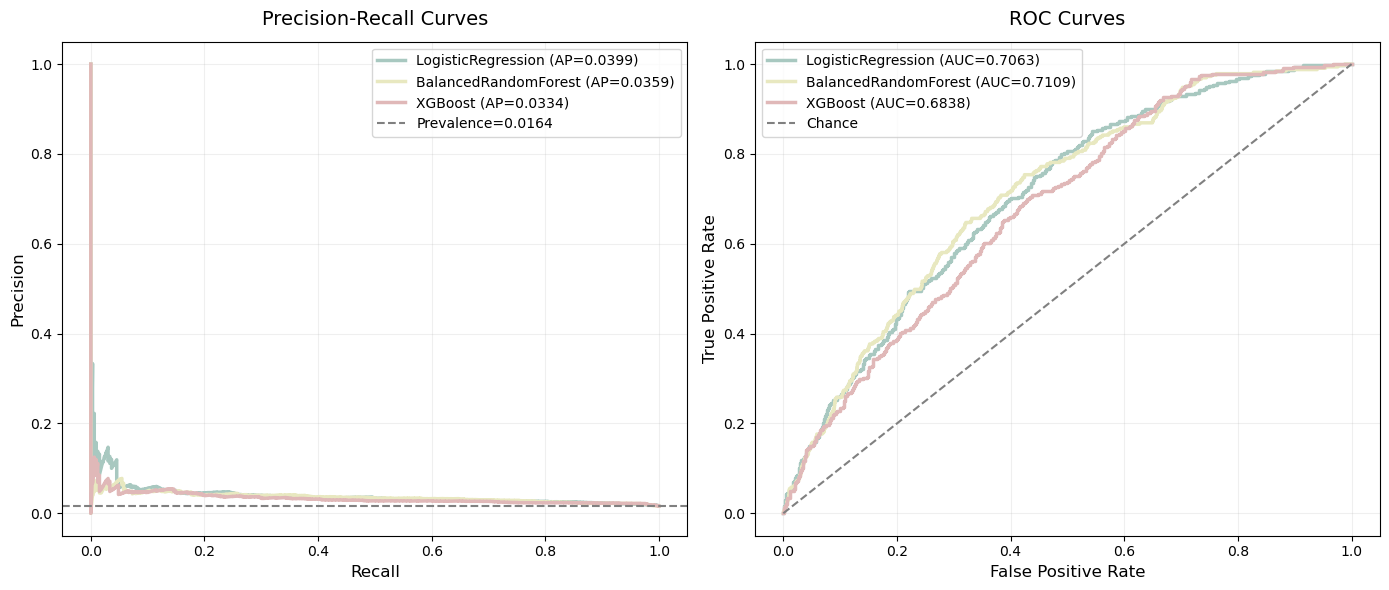

In [145]:
# Combined PR Curve & ROC Curve
plt.figure(figsize=(14, 6))
colors = ['#a8c8c0', '#e8e8c0', '#e0b8b8', '#88a0a8']

# -------------------- Left Subplot: PR Curve --------------------
plt.subplot(1, 2, 1)
baseline = y_test.mean()

for i, model_name in enumerate(models.keys()):
    recall_curve = curve_store[model_name]["recall_curve"]
    precision_curve = curve_store[model_name]["precision_curve"]
    ap = average_precision_score(y_test, curve_store[model_name]["test_prob"])
    plt.plot(recall_curve, precision_curve, color=colors[i], linewidth=2.5,
             label=f"{model_name} (AP={ap:.4f})")

plt.axhline(baseline, linestyle="--", color="gray", linewidth=1.5, label=f"Prevalence={baseline:.4f}")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curves", fontsize=14, pad=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.2)
plt.tight_layout()

# -------------------- Right Subplot: ROC Curve --------------------
plt.subplot(1, 2, 2)
for i, model_name in enumerate(models.keys()):
    fpr = curve_store[model_name]["fpr"]
    tpr = curve_store[model_name]["tpr"]
    auc_ = roc_auc_score(y_test, curve_store[model_name]["test_prob"])
    plt.plot(fpr, tpr, color=colors[i], linewidth=2.5,
             label=f"{model_name} (AUC={auc_:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5, label="Chance")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves", fontsize=14, pad=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.2)
plt.tight_layout()

# Save and show combined figure
plt.savefig("02_pr_and_roc_curves.png", dpi=250, bbox_inches="tight")
plt.show()
plt.close()

These curves confirm that all three models learn useful signal from the dataset, since all of them perform above the random baseline. The Precision-Recall plot is especially important here because the label is highly imbalanced, and it shows that Logistic Regression has the best average precision. The ROC plot shows that Balanced Random Forest has the strongest overall discrimination, while XGBoost is slightly weaker in ranking performance but still remains competitive. Together, these curves suggest that Logistic Regression is strongest for stable risk ranking, Balanced Random Forest is strongest for balanced discrimination, and XGBoost is strongest when recall is prioritized.

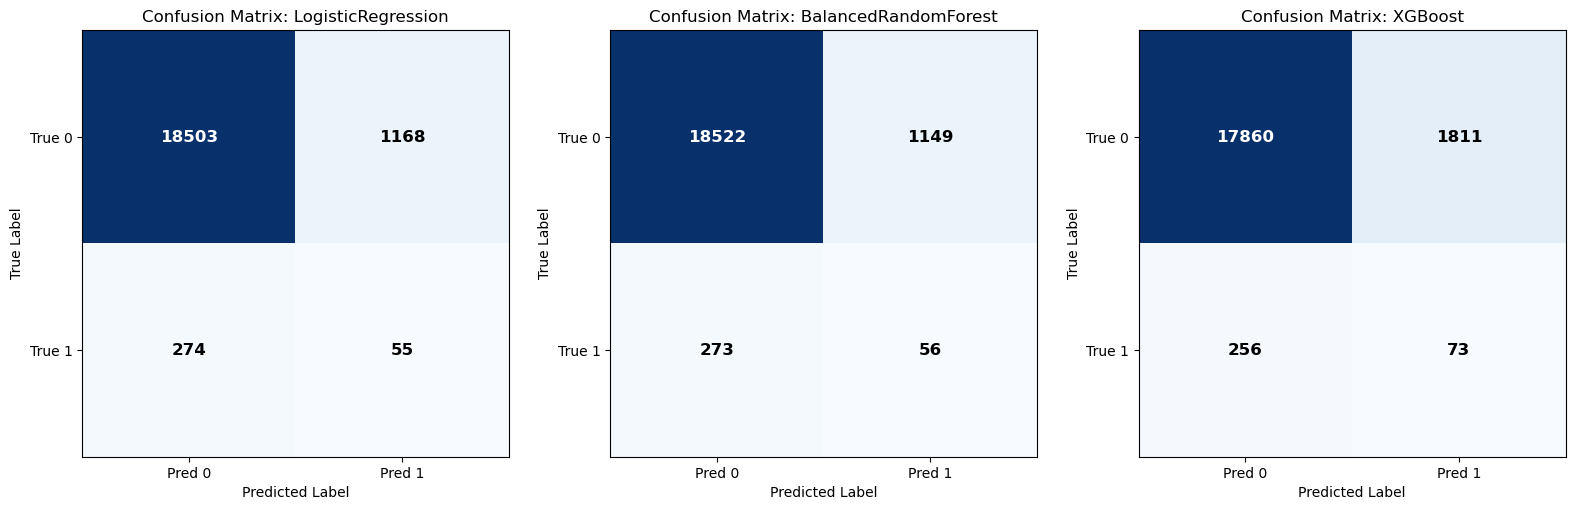

In [146]:
# Plot 3 confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes = axes.flatten()

cmap_custom = "Blues"

# Plot matrix for each model
for idx, model_name in enumerate(models.keys()):
    cm = curve_store[model_name]["cm"]
    ax = axes[idx]

    im = ax.imshow(cm, interpolation="nearest", cmap=cmap_custom)
    ax.set_title(f"Confusion Matrix: {model_name}", fontsize=12)
    
    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["True 0", "True 1"])

    # Set text color based on background
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=12, fontweight='bold'
            )

    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

# Adjust layout and save figure
plt.tight_layout()
plt.savefig("03_confusion_matrices_all_models.png", dpi=250, bbox_inches="tight")
plt.show()
plt.close()

These confusion matrices show the trade-off each model makes between detecting positive readmission cases and avoiding false alarms. Logistic Regression is relatively conservative, identifying fewer true positives while keeping false positives moderate. Balanced Random Forest achieves the most balanced pattern, with slightly better detection and similar false-positive burden. XGBoost identifies the largest number of true positives, which means it has the highest sensitivity, but it also produces the most false positives, so it is the most aggressive model among the three.

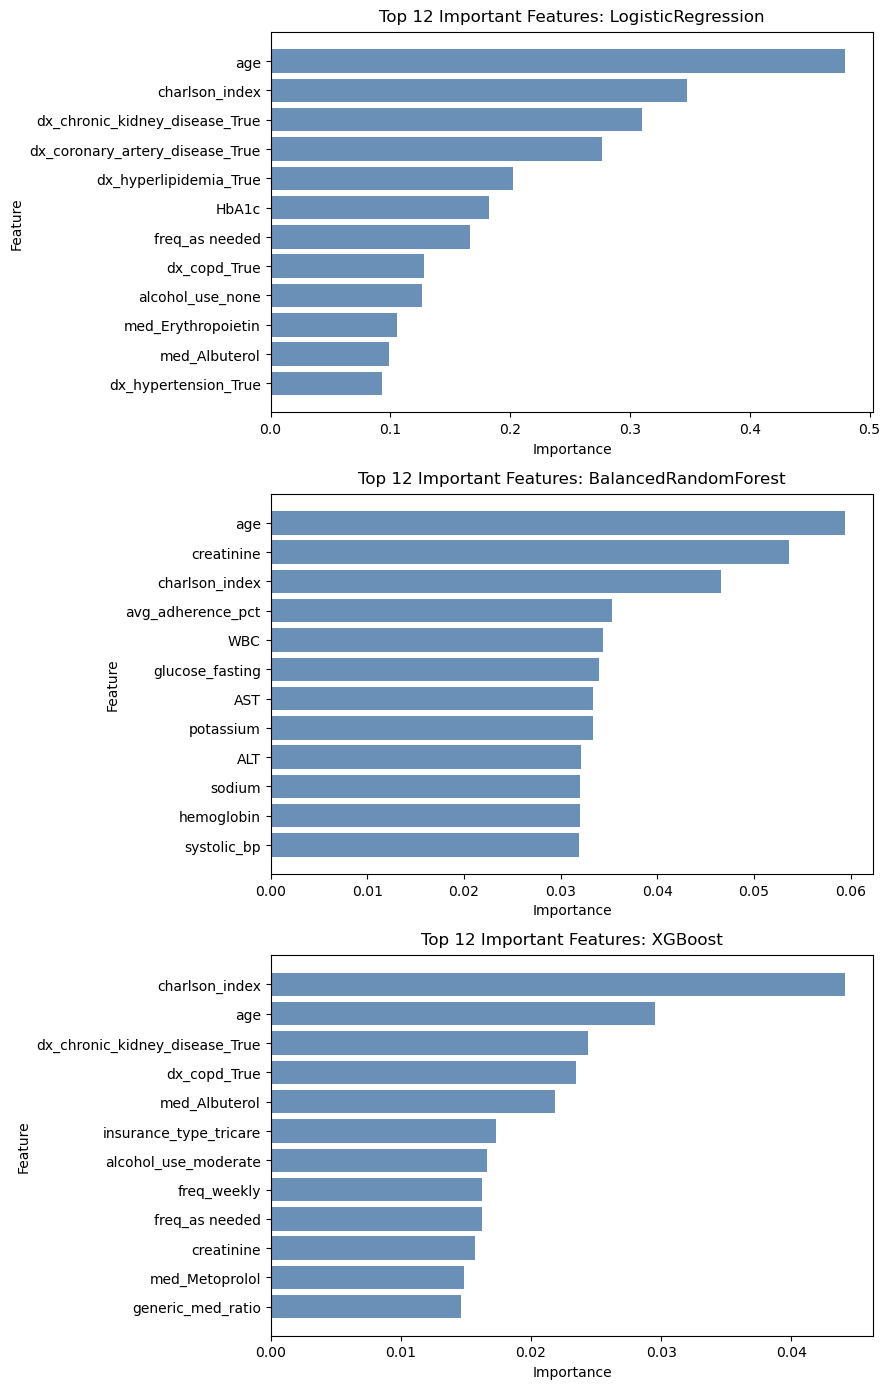

In [147]:
# Plot Top 12 features for 3 models in 3x1 subplots
fig, axes = plt.subplots(3, 1, figsize=(9, 14))
axes = axes.flatten()

bar_color = "#6a90b8"

# Plot each model in a subplot
for idx, model_name in enumerate(models.keys()):
    ax = axes[idx]
    
    # Get top 12 features and reverse order for horizontal bar
    top_sub = (
        feature_importance_df[feature_importance_df["model"] == model_name]
        .head(12)
        .iloc[::-1]
    )
    
    # Plot horizontal bar
    ax.barh(top_sub["feature"], top_sub["importance"], color=bar_color)
    ax.set_title(f"Top 12 Important Features: {model_name}", fontsize=12, pad=8)
    ax.set_xlabel("Importance", fontsize=10)
    ax.set_ylabel("Feature", fontsize=10)

# Adjust layout to align y-axis and avoid text overlap
plt.tight_layout()
plt.savefig("04_top_features_all_models.png", dpi=250, bbox_inches="tight")
plt.show()
plt.close()

This figure shows that the three models rely on overlapping but not identical predictors. Logistic Regression emphasizes stable global risk factors such as age, Charlson index, chronic kidney disease, coronary artery disease, and HbA1c, which makes it behave like a linear risk-scoring model. Balanced Random Forest gives more weight to laboratory and adherence-related variables such as creatinine, WBC, glucose, AST, and adherence percentage, suggesting that it captures nonlinear physiological patterns. XGBoost also highlights Charlson index and age, but additionally uses medication and utilization-related features, showing that it is more sensitive to complex interactions across different clinical domains.

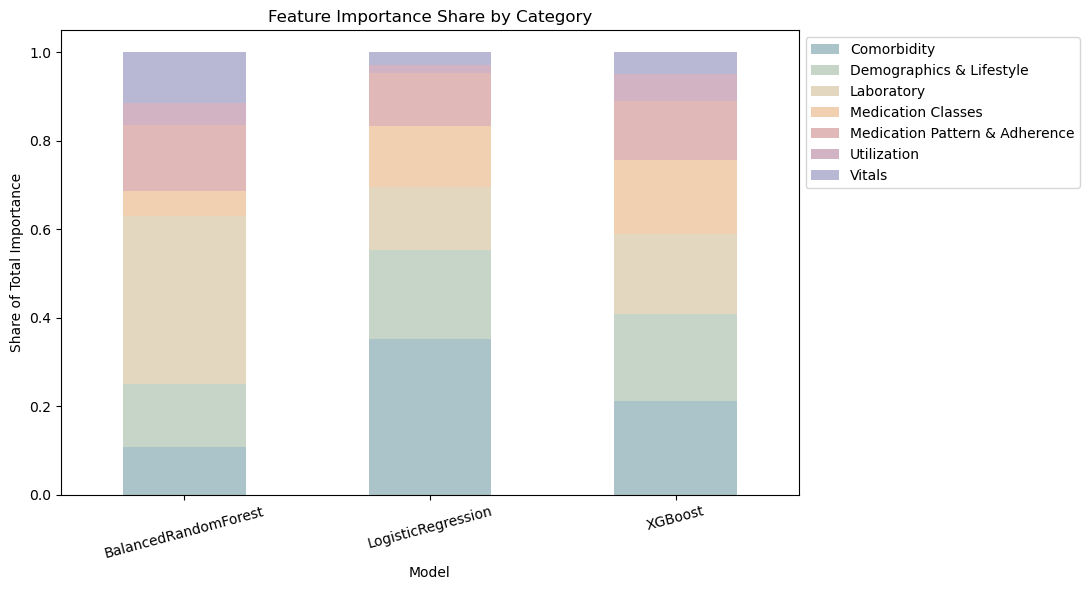

In [148]:
# Stacked bar chart: Feature importance share by category
cat_pivot = cat_share_df.pivot(index="model", columns="category", values="share").fillna(0)
soft_colors = ['#aac4c9', '#c7d5c8', '#e4d7c0', '#f0d0b0', '#e0b8b8', '#d1b3c4', '#b8b8d4']

ax = cat_pivot.plot(kind="bar", stacked=True, figsize=(11, 6), rot=15, color=soft_colors)

ax.set_title("Feature Importance Share by Category")
ax.set_xlabel("Model")
ax.set_ylabel("Share of Total Importance")

# Move legend outside to avoid occlusion
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), fontsize=10)

plt.tight_layout()
plt.savefig("05_feature_category_share_stacked.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

This figure summarizes which types of clinical information each model depends on most. Logistic Regression places more emphasis on comorbidity burden and demographic risk, which is consistent with its more global and interpretable structure. Balanced Random Forest draws heavily from laboratory features, indicating that it benefits from detailed physiological measurements. XGBoost distributes its importance more broadly across comorbidity, laboratory, medication, and demographic categories, suggesting that it integrates multiple sources of information rather than depending on one dominant feature group.

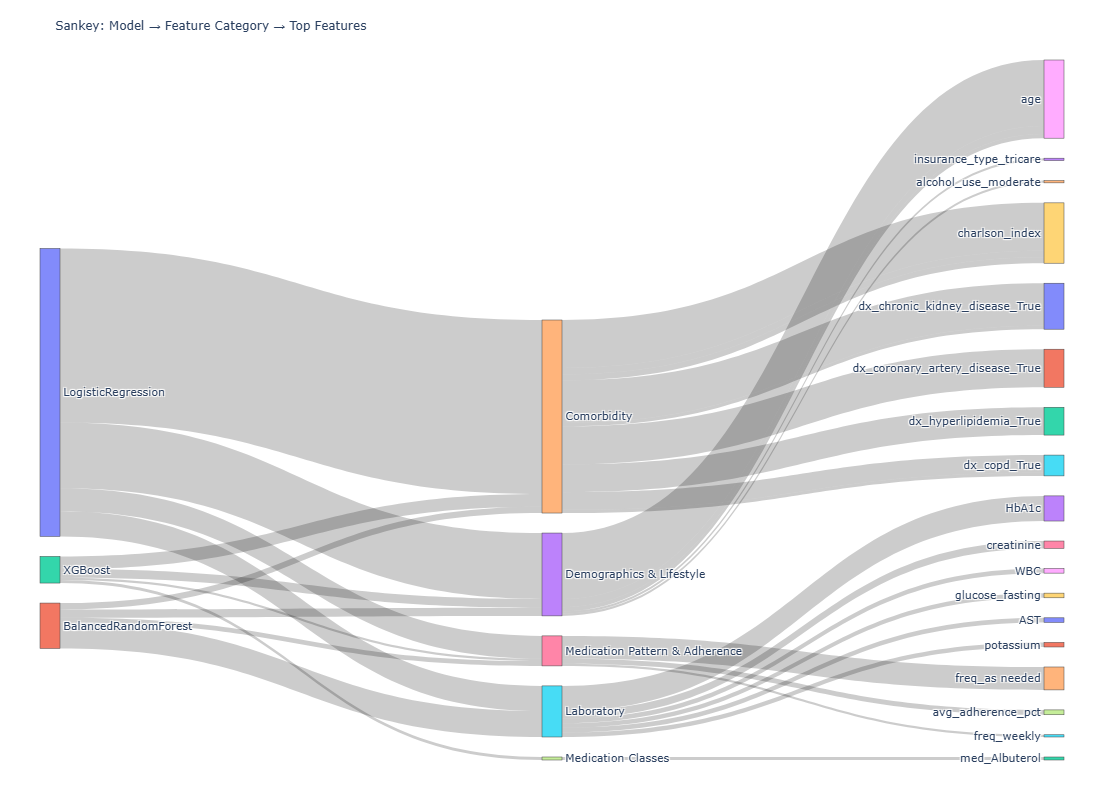

In [149]:
# Sankey Diagram: Model → Feature Category → Top Features
sankey_df = feature_importance_df.groupby("model").head(8).copy()
sankey_df["weight"] = sankey_df["importance"].abs()

# Collect nodes for each level
model_nodes = list(sankey_df["model"].unique())
category_nodes = list(sankey_df["category"].unique())
feature_nodes = list(sankey_df["feature"].unique())

# Combine all nodes and create index mapping
all_nodes = model_nodes + category_nodes + feature_nodes
node_to_idx = {node: i for i, node in enumerate(all_nodes)}

sources = []
targets = []
values = []

# Link: Model → Category
mc_df = sankey_df.groupby(["model", "category"], as_index=False)["weight"].sum()
for _, row in mc_df.iterrows():
    sources.append(node_to_idx[row["model"]])
    targets.append(node_to_idx[row["category"]])
    values.append(float(row["weight"]))

# Link: Category → Feature
for _, row in sankey_df.iterrows():
    sources.append(node_to_idx[row["category"]])
    targets.append(node_to_idx[row["feature"]])
    values.append(float(row["weight"]))

# Create Sankey figure
sankey_fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        label=all_nodes
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
)])

sankey_fig.update_layout(
    title_text="Sankey: Model → Feature Category → Top Features",
    title_font_size=12,
    font_size=11,
    width=1000,
    height=800,
    margin=dict(l=40, r=40, t=60, b=40)
)
sankey_fig.show()
sankey_fig.write_html("06_sankey_model_category_feature.html", include_plotlyjs="cdn")

The Sankey diagram makes the model explanations more intuitive by linking each model to feature categories and then to specific top features. It shows that all three models consistently flow through core categories such as comorbidity, laboratory information, and medication-related patterns, with repeated emphasis on age, Charlson index, chronic kidney disease, creatinine, HbA1c, adherence, and medication-related variables. This means that, despite their methodological differences, the models converge on a common clinical message: readmission risk is mainly driven by multimorbidity, renal dysfunction, metabolic and laboratory abnormalities, and treatment complexity.

## Conclusion

These figures summarizes which types of clinical information each model depends on most. Logistic Regression places more emphasis on comorbidity burden and demographic risk, which is consistent with its more global and interpretable structure. Balanced Random Forest draws heavily from laboratory features, indicating that it benefits from detailed physiological measurements. XGBoost distributes its importance more broadly across comorbidity, laboratory, medication, and demographic categories, suggesting that it integrates multiple sources of information rather than depending on one dominant feature group.

After conducting feature engineering and filtering on the overall table, we constructed a three-model classification experiment for readmitted_30d and presented the results from both performance and interpretability perspectives. The model result table illustrates the differences in algorithm choices for imbalanced medical data, while the analysis of feature importance and feature categories further explains that the model mainly relies on age, comorbidity burden, renal function, laboratory abnormalities, and medication management information.
In the supervised learning section, we compared three models: Logistic Regression, Balanced Random Forest, and XGBoost. In terms of results, the ROC-AUC of Balanced Random Forest was the highest (approximately 0.711), indicating that it has the best overall discrimination ability; the PR-AUC of Logistic Regression was slightly higher, indicating that it has a more stable risk ranking in extremely imbalanced data; the Recall of XGBoost was the highest (approximately 0.222), indicating that it captured more positive cases, but at the cost of more false positives. The differences among these three models are in line with the characteristics of the models themselves, and also demonstrate that our experimental approach is valid: not just looking at a single indicator, but comparing the advantages of different models in different goals.